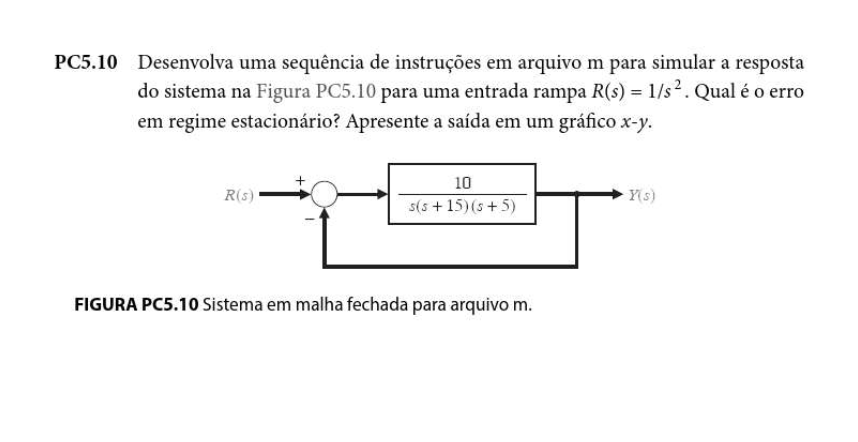

PROBLEMA PC5.10 - RESPOSTA A RAMPA E ERRO EM REGIME ESTACIONÁRIO

(1) FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:
-------------------------------------------------------------------------------------

L(s) = G(s) = 10/(s(s+15)(s+5)) =
<TransferFunction>: sys[7]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          10
  -------------------
  s^3 + 20 s^2 + 75 s

FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:
T(s) = L(s)/(1 + L(s)) = Y(s)/R(s) =
<TransferFunction>: sys[9]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             10
  ------------------------
  s^3 + 20 s^2 + 75 s + 10

Numerador de T(s): [10]
Denominador de T(s): [ 1 20 75 10]

ANÁLISE DE ESTABILIDADE:

Pólos do sistema em malha fechada:
  Pólo 1: -15.065940
  Pólo 2: -4.795654
  Pólo 3: -0.138406

Estabilidade: ESTÁVEL

ERRO EM REGIME ESTACIONÁRIO:

Constante de erro de velocidade:
  K_v = lim(s→0) s*L(s) = 10/(15×5) = 0.133333

Erro em regime estacionário para rampa unitária:
  e_ss = 1/K_v = 1/0.133333 = 7.500000

SIMULAÇÃO DA

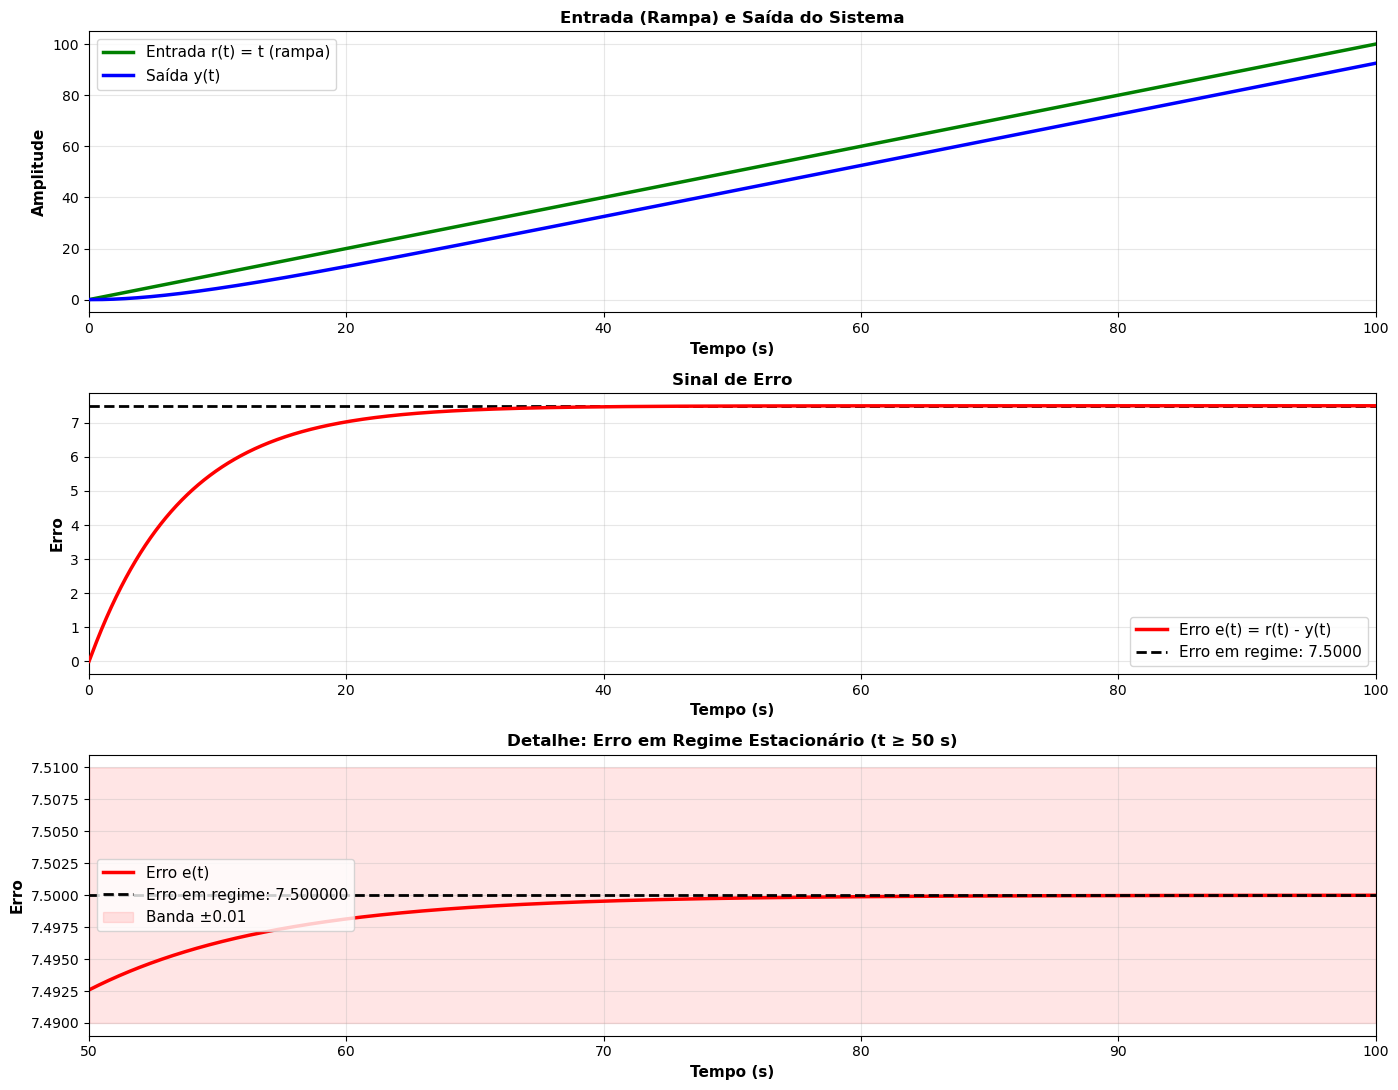


TIPO DE SISTEMA:

Tipo de Sistema: Tipo 1 (uma integração)
  - Erro zero para entrada em degrau: SIM
  - Erro finito para entrada em rampa: SIM (e_ss = 1/K_v)
  - Erro infinito para entrada em parábola: SIM

RESUMO FINAL:

✓ Entrada: r(t) = t (rampa unitária)
✓ Erro em regime estacionário teórico: e_ss = 7.500000
✓ Erro em regime estacionário simulado: e_ss ≈ 7.499993
✓ Sistema: ESTÁVEL (Tipo 1)

✓ Gráficos salvos como 'ramp_response_pc510.png'


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

print("=" * 85)
print("PROBLEMA PC5.10 - RESPOSTA A RAMPA E ERRO EM REGIME ESTACIONÁRIO")
print("=" * 85)

# Define the system components
# Open-loop transfer function: L(s) = 10/(s(s+15)(s+5))
# Unity negative feedback

print("\n(1) FUNÇÃO DE TRANSFERÊNCIA EM MALHA ABERTA:")
print("-" * 85)

# Open-loop transfer function: L(s) = 10/(s(s+15)(s+5))
num_L = [10]                    # numerador: 10
den_L = [1, 20, 75, 0]          # denominador: s³ + 20s² + 75s

# Verify denominator: s(s+15)(s+5) = s(s² + 20s + 75) = s³ + 20s² + 75s

L = ct.TransferFunction(num_L, den_L)
print("\nL(s) = G(s) = 10/(s(s+15)(s+5)) =")
print(L)

# Calculate closed-loop transfer function: T(s) = L(s)/(1 + L(s))
T = ct.feedback(L)

print("\n" + "=" * 85)
print("FUNÇÃO DE TRANSFERÊNCIA EM MALHA FECHADA:")
print("=" * 85)
print("T(s) = L(s)/(1 + L(s)) = Y(s)/R(s) =")
print(T)

# Extract numerator and denominator
num_T, den_T = ct.tfdata(T)
num_T = num_T[0][0]
den_T_flat = np.asarray(den_T[0]).flatten()

print("\nNumerador de T(s):", num_T)
print("Denominador de T(s):", den_T_flat)

# Analyze poles and stability
print("\n" + "=" * 85)
print("ANÁLISE DE ESTABILIDADE:")
print("=" * 85)

poles = np.roots(den_T_flat)
print("\nPólos do sistema em malha fechada:")
for i, pole in enumerate(poles):
    if np.isreal(pole):
        print(f"  Pólo {i+1}: {pole.real:.6f}")
    else:
        print(f"  Pólo {i+1}: {pole.real:.6f} ± j{abs(pole.imag):.6f}")

is_stable = all(p.real < 0 for p in poles)
print(f"\nEstabilidade: {'ESTÁVEL' if is_stable else 'INSTÁVEL'}")

# Calculate steady-state error for ramp input
print("\n" + "=" * 85)
print("ERRO EM REGIME ESTACIONÁRIO:")
print("=" * 85)

# For a system with unity negative feedback:
# e_ss = lim(t→∞) [r(t) - y(t)]
# For a ramp input r(t) = t, the steady-state error is e_ss = 1/K_v
# where K_v = lim(s→0) s*L(s) (velocity error constant)

# Calculate K_v
# K_v = lim(s→0) s*L(s) = lim(s→0) s * 10/(s(s+15)(s+5))
#     = lim(s→0) 10/((s+15)(s+5)) = 10/(15*5) = 10/75 = 2/15

K_v_theoretical = 10 / (15 * 5)
e_ss_theoretical = 1 / K_v_theoretical

print(f"\nConstante de erro de velocidade:")
print(f"  K_v = lim(s→0) s*L(s) = 10/(15×5) = {K_v_theoretical:.6f}")

print(f"\nErro em regime estacionário para rampa unitária:")
print(f"  e_ss = 1/K_v = 1/{K_v_theoretical:.6f} = {e_ss_theoretical:.6f}")

# Simulate response to ramp input
print("\n" + "=" * 85)
print("SIMULAÇÃO DA RESPOSTA À RAMPA:")
print("=" * 85)

# Create time vector
t = np.linspace(0, 100, 5000)

# Create ramp input: r(t) = t
r = t

# Calculate system response using forced_response
t_out, y = ct.forced_response(T, T=t, U=r)

# Calculate error: e(t) = r(t) - y(t)
e = r - y

# Steady-state error (at the end of simulation)
e_ss_simulated = e[-1]

print(f"\nRESULTADOS DA SIMULAÇÃO (t = {t[-1]} s):")
print(f"  Entrada r(t) = {r[-1]:.6f}")
print(f"  Saída y(t) = {y[-1]:.6f}")
print(f"  Erro e(t) = {e_ss_simulated:.6f}")

print(f"\nCOMPARAÇÃO:")
print(f"  Erro teórico:   {e_ss_theoretical:.6f}")
print(f"  Erro simulado:  {e_ss_simulated:.6f}")
print(f"  Diferença:      {abs(e_ss_theoretical - e_ss_simulated):.6f}")

# Find when error stabilizes (approaches steady-state)
# Look for the point where error is approximately constant
error_derivative = np.gradient(e)
steady_state_idx = None
for i in range(len(error_derivative) - 1, 0, -1):
    if abs(error_derivative[i]) < 1e-4:  # Nearly zero derivative
        steady_state_idx = i
        break

if steady_state_idx:
    time_to_steady_state = t_out[steady_state_idx]
    print(f"\nTempo para atingir regime estacionário: ~{time_to_steady_state:.2f} s")
else:
    print(f"\nSistema ainda não atingiu regime estacionário em {t[-1]} s")

# Create comprehensive plot
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Plot 1: Input and output
ax1 = axes[0]
ax1.plot(t_out, r, 'g-', linewidth=2.5, label='Entrada r(t) = t (rampa)', zorder=3)
ax1.plot(t_out, y, 'b-', linewidth=2.5, label='Saída y(t)', zorder=3)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=11, fontweight='bold')
ax1.set_title('Entrada (Rampa) e Saída do Sistema', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.set_xlim(0, 100)

# Plot 2: Error signal
ax2 = axes[1]
ax2.plot(t_out, e, 'r-', linewidth=2.5, label='Erro e(t) = r(t) - y(t)', zorder=3)
ax2.axhline(y=e_ss_theoretical, color='k', linestyle='--', linewidth=2, label=f'Erro em regime: {e_ss_theoretical:.4f}')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Erro', fontsize=11, fontweight='bold')
ax2.set_title('Sinal de Erro', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)
ax2.set_xlim(0, 100)

# Plot 3: Zoomed view of steady-state region
ax3 = axes[2]
start_idx = np.where(t_out >= 50)[0][0]
ax3.plot(t_out[start_idx:], e[start_idx:], 'r-', linewidth=2.5, label='Erro e(t)')
ax3.axhline(y=e_ss_theoretical, color='k', linestyle='--', linewidth=2, 
           label=f'Erro em regime: {e_ss_theoretical:.6f}')
ax3.fill_between(t_out[start_idx:], e_ss_theoretical - 0.01, e_ss_theoretical + 0.01, 
                 alpha=0.1, color='red', label='Banda ±0.01')
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('Tempo (s)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Erro', fontsize=11, fontweight='bold')
ax3.set_title('Detalhe: Erro em Regime Estacionário (t ≥ 50 s)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=11)
ax3.set_xlim(50, 100)

plt.tight_layout()
plt.savefig('ramp_response_pc510.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional analysis: Check system type
print("\n" + "=" * 85)
print("TIPO DE SISTEMA:")
print("=" * 85)

# System type is determined by the number of integrators in L(s)
# L(s) = 10/(s(s+15)(s+5)) has 1 integrator (s in denominator)
# So this is a Type 1 system

print(f"\nTipo de Sistema: Tipo 1 (uma integração)")
print(f"  - Erro zero para entrada em degrau: SIM")
print(f"  - Erro finito para entrada em rampa: SIM (e_ss = 1/K_v)")
print(f"  - Erro infinito para entrada em parábola: SIM")

print("\n" + "=" * 85)
print("RESUMO FINAL:")
print("=" * 85)
print(f"\n✓ Entrada: r(t) = t (rampa unitária)")
print(f"✓ Erro em regime estacionário teórico: e_ss = {e_ss_theoretical:.6f}")
print(f"✓ Erro em regime estacionário simulado: e_ss ≈ {e_ss_simulated:.6f}")
print(f"✓ Sistema: ESTÁVEL (Tipo 1)")
print(f"\n✓ Gráficos salvos como 'ramp_response_pc510.png'")
print("=" * 85)